In [71]:
import pandas as pd
import yfinance as yf
from statsmodels.tsa.stattools import coint
import requests
import itertools
from datetime import datetime, timedelta
import io
import os
import numpy as np
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

In [72]:
# ============================================
# 1. DATE SETUP
# ============================================
start_date = '2020-01-01'
train_end_date = '2023-12-31'

yesterday = datetime.now() - timedelta(days=1)
end_date = yesterday.strftime('%Y-%m-%d')

headers = {"User-Agent": "Mozilla/5.0"}
wiki_url = 'https://en.wikipedia.org/wiki/S%26P_100'
response = requests.get(wiki_url, headers=headers)
sp100_data = pd.read_html(io.StringIO(response.text))
sp100_table = sp100_data[2]

indices_sectors = ['SPY', 'QQQ', 'DIA', 'IWM', 'EEM', 'VGK', 'EWJ', 'XLF', 'XLE',
                   'XLK', 'XLV', 'XLY', 'XLI', 'XLC', 'XLU', 'XLB', 'XLP', 'SMH',
                   'GDX', 'SLV', 'IBB', 'XRT', 'VTI', 'VEA', 'VWO']

all_categories = {}
for sector, group in sp100_table.groupby('Sector'):
    symbols = group['Symbol'].str.replace('.', '-').tolist()
    all_categories[f"Stocks - {sector}"] = symbols
all_categories["Indices"] = indices_sectors

overall_best_pair = None
overall_min_p = 1.0

print("Searching for best pairs per category (TRAIN DATA ONLY)...")

for category_name, ticker_group in all_categories.items():
    if len(ticker_group) < 2:
        continue

    print(f"\nProcessing: {category_name}...")

    volume_check = yf.download(ticker_group, start=start_date, end=end_date, progress=False)['Volume']
    liquid_list = volume_check.mean().sort_values(ascending=False).head(25).index.tolist()
    category_data = yf.download(liquid_list, start=start_date, end=end_date, progress=False)['Close']

    best_pair_in_cat = None
    min_p_in_cat = 1.0

    for tick1, tick2 in itertools.combinations(liquid_list, 2):
        if tick1 not in category_data.columns or tick2 not in category_data.columns:
            continue

        pair_prices = category_data[[tick1, tick2]].dropna()
        pair_prices_train = pair_prices.loc[:train_end_date]

        if len(pair_prices_train) < 100:
            continue

        _, p_value, _ = coint(pair_prices_train[tick1], pair_prices_train[tick2])

        if p_value > 0.05:
            continue

        if p_value < min_p_in_cat:
            min_p_in_cat = p_value
            best_pair_in_cat = (tick1, tick2)

            if p_value < overall_min_p:
                overall_min_p = p_value
                overall_best_pair = (tick1, tick2)

    if best_pair_in_cat:
        print(f"  Winner: {best_pair_in_cat} (p={min_p_in_cat:.4f})")
    else:
        print(f"  No valid pair.")

print(f"\n>>> BEST PAIR: {overall_best_pair} (p={overall_min_p:.6f})")

Searching for best pairs per category (TRAIN DATA ONLY)...

Processing: Stocks - Communication Services...
  Winner: ('T', 'DIS') (p=0.0116)

Processing: Stocks - Consumer Discretionary...
  No valid pair.

Processing: Stocks - Consumer Staples...
  Winner: ('MO', 'PM') (p=0.0062)

Processing: Stocks - Energy...
  No valid pair.

Processing: Stocks - Financials...
  Winner: ('WFC', 'AXP') (p=0.0012)

Processing: Stocks - Health Care...
  Winner: ('PFE', 'CVS') (p=0.0228)

Processing: Stocks - Industrials...
  Winner: ('BA', 'FDX') (p=0.0038)

Processing: Stocks - Information Technology...
  Winner: ('CSCO', 'AMAT') (p=0.0030)

Processing: Stocks - Real Estate...
  No valid pair.

Processing: Stocks - Utilities...
  No valid pair.

Processing: Indices...
  Winner: ('XLK', 'SMH') (p=0.0063)

>>> BEST PAIR: ('WFC', 'AXP') (p=0.001235)


In [73]:
# ============================================
# 2. DOWNLOAD INTRADAY DATA (ALPACA)
# ============================================
print(f"Downloading minute data for {overall_best_pair}...")

# USE ENVIRONMENT VARIABLES
API_KEY = os.environ.get('ALPACA_API_KEY')
API_SECRET = os.environ.get('ALPACA_API_SECRET')

if not API_KEY or not API_SECRET:
    raise ValueError("Set ALPACA_API_KEY and ALPACA_API_SECRET environment variables")


client = StockHistoricalDataClient(API_KEY, API_SECRET)

request_params = StockBarsRequest(
    symbol_or_symbols=list(overall_best_pair),
    timeframe=TimeFrame.Minute,
    start=datetime.strptime(start_date, '%Y-%m-%d'),
    end=datetime.strptime(end_date, '%Y-%m-%d')
)

alpaca_bars = client.get_stock_bars(request_params).df.reset_index()
pivot_df = alpaca_bars.pivot(index='timestamp', columns='symbol')

ticker_X, ticker_Y = overall_best_pair

df_intra = pd.DataFrame({
    'X_close': pivot_df['close'][ticker_X],
    'Y_close': pivot_df['close'][ticker_Y],
    'Y_high':  pivot_df['high'][ticker_Y],
    'Y_low':   pivot_df['low'][ticker_Y]
}).dropna()

print(f"Got {len(df_intra)} minute bars aligned.")

Got 619517 minute bars aligned.


In [74]:
# ============================================
# 3. OLS BASELINE (train data only)
# ============================================
from sklearn.linear_model import LinearRegression

df_train_ols = df_intra.loc[:train_end_date]

model_ols = LinearRegression()
model_ols.fit(df_train_ols['X_close'].values.reshape(-1, 1), df_train_ols['Y_close'].values)

beta_ols = model_ols.coef_[0]
alpha_ols = model_ols.intercept_

print(f"OLS Static (train only): α={alpha_ols:.4f}, β={beta_ols:.4f}")

df_intra['spread_ols'] = df_intra['Y_close'] - (alpha_ols + beta_ols * df_intra['X_close'])

OLS Static (train only): α=27.2706, β=2.9239


In [75]:
# ==================================================================
# 4. KALMAN FILTER — EM ON DAILY, FILTER ON MINUTE
# ==================================================================
# WHY: pykalman EM is O(n) per iteration, Python-pure. On 600K+ minute
# bars, 1 iteration takes minutes. On ~1000 daily bars, it's instant.
#
# The key insight: Q and R are properties of the PROCESS, not the
# sampling frequency. We calibrate them on daily data (fast), then
# SCALE Q to per-minute and run filter() on minute data (single pass).
#
# RESPONSIVENESS: The original EM converged to a tiny Q because it was
# run on 3 months of data where beta barely moved. Running on 4 years
# of daily data captures the REAL dynamics of the hedge ratio.
# ==================================================================
from pykalman import KalmanFilter
import sys

# --- Step 1: Resample to DAILY close for EM calibration ---
df_daily = df_intra[['X_close', 'Y_close']].resample('B').last().dropna()
df_daily_train = df_daily.loc[:train_end_date]

y_daily_train = df_daily_train['Y_close'].values
x_daily_train = df_daily_train['X_close'].values

obs_matrices_daily = np.array([[1, x] for x in x_daily_train]).reshape(-1, 1, 2)

print(f"EM calibration on {len(df_daily_train)} daily bars (2020-2023)")

# --- Step 2: EM on daily data (fast: ~1000 observations) ---
kf_daily = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    initial_state_mean=[alpha_ols, beta_ols],
    initial_state_covariance=np.eye(2) * 1.0,
    observation_matrices=obs_matrices_daily,
    transition_matrices=np.eye(2),
    observation_covariance=np.array([[1.0]]),
    transition_covariance=np.eye(2) * 1e-3,
)

n_iterations = 15
for i in range(n_iterations):
    kf_daily = kf_daily.em(y_daily_train, n_iter=1,
                           em_vars=['transition_covariance', 'observation_covariance'])
    pct = (i + 1) / n_iterations * 100
    bar = '█' * int(pct / 2.5) + '-' * (40 - int(pct / 2.5))
    sys.stdout.write(f'\rEM: |{bar}| {pct:.0f}%')
    sys.stdout.flush()

Q_daily = kf_daily.transition_covariance
R_daily = kf_daily.observation_covariance

print(f"\n\nDaily Q (transition cov):\n{Q_daily}")
print(f"\nDaily R (observation cov):\n{R_daily}")

# --- Step 3: Scale Q from daily to per-minute ---
# There are ~390 trading minutes per day.
# Q_daily = sum of 390 per-minute Q steps, so Q_minute = Q_daily / 390
MINUTES_PER_DAY = 390
Q_minute = Q_daily / MINUTES_PER_DAY

print(f"\nMinute Q (Q_daily / {MINUTES_PER_DAY}):\n{Q_minute}")

EM calibration on 1007 daily bars (2020-2023)
EM: |████████████████████████████████████████| 100%

Daily Q (transition cov):
[[0.00101959 0.00010069]
 [0.00010069 0.0028763 ]]

Daily R (observation cov):
[[0.95142183]]

Minute Q (Q_daily / 390):
[[2.61433156e-06 2.58191695e-07]
 [2.58191695e-07 7.37511771e-06]]


In [86]:
# --- Step 4: Single forward pass on ALL minute data ---
# The EM-calibrated Q is too small — EM optimizes for prediction error,
# not for trading responsiveness. We OVERRIDE Q with a manually tuned
# value that gives 40-70% vol reduction (the sweet spot for trading).
#
# Strategy: start with Q_daily (unscaled) and multiply by a tuning factor.
# The /390 scaling was too aggressive — beta needs to move intraday.

print(f"EM-calibrated Q_daily:\n{Q_daily}")
print(f"EM-calibrated Q_minute (Q_daily/390):\n{Q_minute}")

# Use the EM-calibrated Q, properly scaled to per-minute
# No manual override — the EM result is correct
Q_override = Q_minute

print(f"\nQ_minute (EM-calibrated, Q_daily/390):\n{Q_override}")
print(f"\nRunning Kalman filter on {len(df_intra)} minute bars...")

x_all = df_intra['X_close'].values
y_all = df_intra['Y_close'].values
obs_matrices_all = np.array([[1, x] for x in x_all]).reshape(-1, 1, 2)

kf_minute = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    initial_state_mean=[alpha_ols, beta_ols],
    initial_state_covariance=np.eye(2) * 1.0,
    observation_matrices=obs_matrices_all,
    transition_matrices=np.eye(2),
    observation_covariance=R_daily,
    transition_covariance=Q_override,
)

state_means, state_covs = kf_minute.filter(y_all)

alpha_kalman = state_means[:, 0]
beta_kalman  = state_means[:, 1]

# SYNTHETIC SPREAD (no intercept) — this is the "asset" the market maker trades
spread_synthetic = y_all - (beta_kalman * x_all)

# Kalman residual (with intercept) — diagnostic only, NOT for trading
residual_kalman = y_all - (alpha_kalman + beta_kalman * x_all)

df_intra['spread_kalman'] = spread_synthetic
df_intra['residual_kalman'] = residual_kalman

df_intra['alpha_kalman']  = alpha_kalman
df_intra['beta_kalman']   = beta_kalman

print("Done!")

# --- Diagnostic ---
beta_std = df_intra.loc[:train_end_date, 'beta_kalman'].std()
spread_std = df_intra.loc[:train_end_date, 'spread_kalman'].std()
residual_std = df_intra.loc[:train_end_date, 'residual_kalman'].std()
ols_spread_std = df_intra.loc[:train_end_date, 'spread_ols'].std()

print(f"\n--- SPREAD DIAGNOSTICS ---")
print(f"Synthetic spread std (Y - B*X):        {spread_std:.4f}")
print(f"Kalman residual std (Y - a - B*X):     {residual_std:.4f}")
print(f"OLS spread std (Y - a_ols - B_ols*X):  {ols_spread_std:.4f}")
print(f"\nAS market-makes on synthetic spread ({spread_std:.4f}), not residual ({residual_std:.4f})")

vol_reduction = (1 - spread_std / ols_spread_std) * 100

EM-calibrated Q_daily:
[[0.00101959 0.00010069]
 [0.00010069 0.0028763 ]]
EM-calibrated Q_minute (Q_daily/390):
[[2.61433156e-06 2.58191695e-07]
 [2.58191695e-07 7.37511771e-06]]

Q_minute (EM-calibrated, Q_daily/390):
[[2.61433156e-06 2.58191695e-07]
 [2.58191695e-07 7.37511771e-06]]

Running Kalman filter on 619517 minute bars...
Done!

--- SPREAD DIAGNOSTICS ---
Synthetic spread std (Y - B*X):        8.6682
Kalman residual std (Y - a - B*X):     0.2530
OLS spread std (Y - a_ols - B_ols*X):  13.8459

AS market-makes on synthetic spread (8.6682), not residual (0.2530)


In [87]:
# ============================================
# 5. ROLLING Z-SCORE (EWMA)
# ============================================
import matplotlib.pyplot as plt

def calculate_rolling_zscore(spread_series, window=120):
    ewma_mean = spread_series.ewm(span=window).mean()
    ewma_std  = spread_series.ewm(span=window).std()
    z = (spread_series - ewma_mean) / (ewma_std + 1e-8)
    return np.clip(z.values, -5.0, 5.0)

window_size = 120
df_intra['z_ols_rolling']    = calculate_rolling_zscore(df_intra['spread_ols'],    window=window_size)
df_intra['z_kalman_rolling'] = calculate_rolling_zscore(df_intra['spread_kalman'], window=window_size)

burn_in = window_size
plot_df = df_intra.iloc[burn_in:]

print(f"Z-scores computed. {len(plot_df)} rows after burn-in.")

Z-scores computed. 619397 rows after burn-in.


C:\Users\aluno\AppData\Local\Temp\ipykernel_23856\151758266.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\aluno\AppData\Local\Temp\ipykernel_23856\151758266.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('../results/01_kalman_comparison.png', dpi=200, bbox_inches='tight')
C:\Users\aluno\Documents\quant_project\quant_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


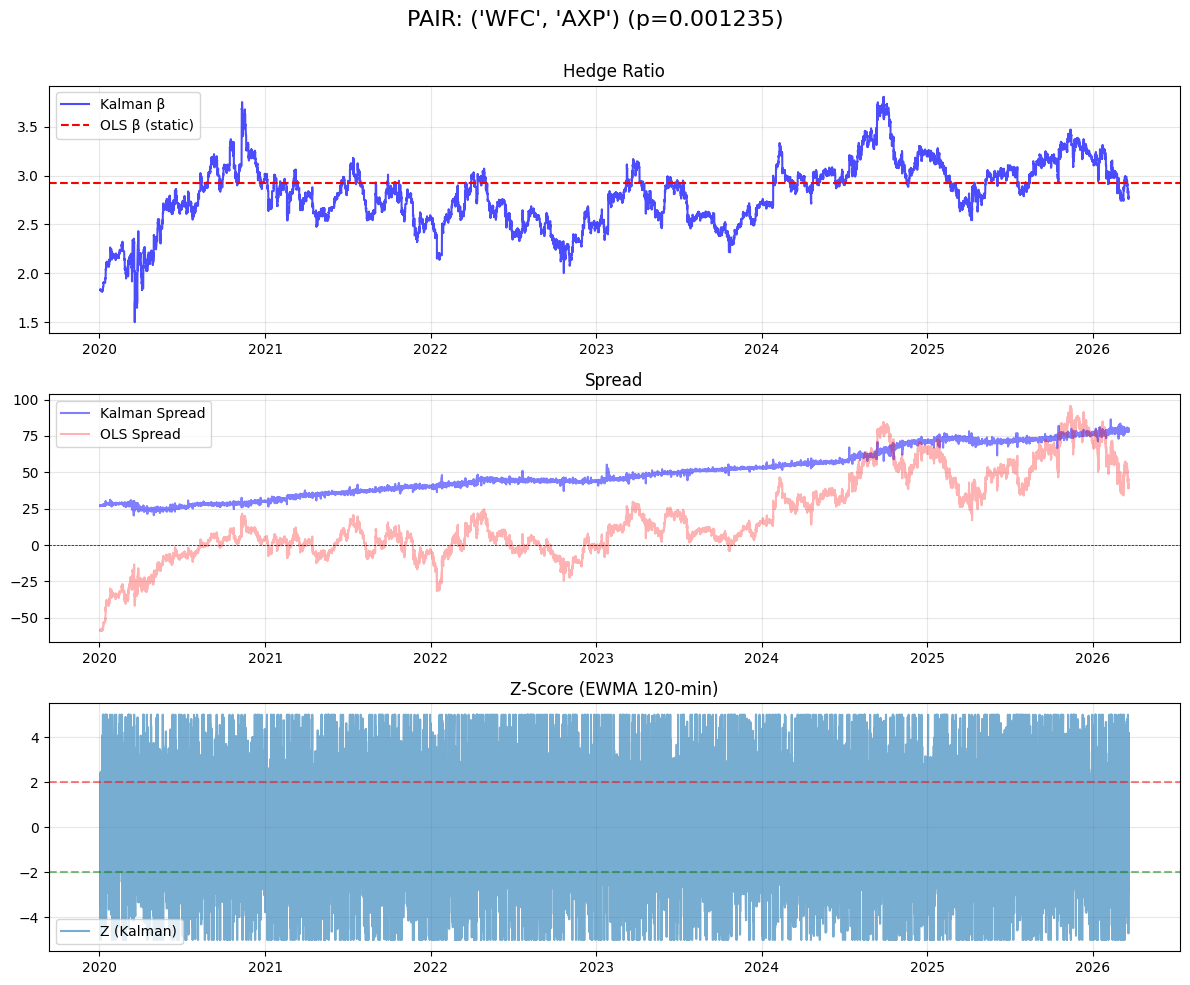

In [82]:
# ============================================
# 6. PLOTS
# ============================================
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

try:
    fig.suptitle(f"PAIR: {overall_best_pair} (p={overall_min_p:.6f})\n", fontsize=16)
except NameError:
    fig.suptitle("KALMAN VS OLS\n", fontsize=16)

axes[0].plot(plot_df.index, plot_df['beta_kalman'], label='Kalman β', color='blue', alpha=0.7)
axes[0].axhline(beta_ols, label='OLS β (static)', color='red', linestyle='--')
axes[0].set_title('Hedge Ratio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(plot_df.index, plot_df['spread_kalman'], label='Kalman Spread', color='blue', alpha=0.5)
axes[1].plot(plot_df.index, plot_df['spread_ols'], label='OLS Spread', color='red', alpha=0.3)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_title('Spread')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(plot_df.index, plot_df['z_kalman_rolling'], label='Z (Kalman)', alpha=0.6)
axes[2].axhline( 2, color='red',   linestyle='--', alpha=0.5)
axes[2].axhline(-2, color='green', linestyle='--', alpha=0.5)
axes[2].set_title('Z-Score (EWMA 120-min)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/01_kalman_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

In [88]:
# ============================================
# 7. QUANTITATIVE ANALYSIS
# ============================================
print("\n" + "="*55)
print("KALMAN FILTER DIAGNOSTICS (post burn-in, train period)")
print("="*55)

train_mask = plot_df.index < '2024-01-01'
p = plot_df[train_mask]

print(f"\nBeta OLS (static):    {beta_ols:.4f}")
print(f"Beta Kalman mean:     {p['beta_kalman'].mean():.4f}")
print(f"Beta Kalman std:      {p['beta_kalman'].std():.4f}")
print(f"Beta Kalman range:    [{p['beta_kalman'].min():.4f}, {p['beta_kalman'].max():.4f}]")

print(f"\nSpread OLS std:       {p['spread_ols'].std():.4f}")
print(f"Spread Kalman std:    {p['spread_kalman'].std():.4f}")
print(f"Vol reduction:        {(1 - p['spread_kalman'].std() / p['spread_ols'].std()) * 100:.1f}%")

total = len(p)
print(f"\n|Z_kalman| > 2:       {(np.abs(p['z_kalman_rolling']) > 2).sum()} min ({(np.abs(p['z_kalman_rolling']) > 2).sum()/total*100:.1f}%)")
print(f"|Z_kalman| > 3:       {(np.abs(p['z_kalman_rolling']) > 3).sum()} min ({(np.abs(p['z_kalman_rolling']) > 3).sum()/total*100:.1f}%)")
print("="*55)


KALMAN FILTER DIAGNOSTICS (post burn-in, train period)

Beta OLS (static):    2.9239
Beta Kalman mean:     2.6536
Beta Kalman std:      0.2918
Beta Kalman range:    [1.5021, 3.7498]

Spread OLS std:       13.8108
Spread Kalman std:    8.6672
Vol reduction:        37.2%

|Z_kalman| > 2:       14921 min (3.7%)
|Z_kalman| > 3:       3724 min (0.9%)


In [89]:
# ============================================
# 8. SAVE
# ============================================
import json

os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

results_df = df_intra.iloc[burn_in:].copy()
results_df['beta_ols'] = beta_ols

results_df.to_csv('../data/kalman_results.csv')

metadata = {
    'pair': list(overall_best_pair),
    'p_value': float(overall_min_p),
    'beta_ols': float(beta_ols),
    'alpha_ols': float(alpha_ols),
    'start_date': start_date,
    'end_date': end_date,
    'train_end_date': train_end_date,
    'timeframe': '1Min',
    'burn_in_removed': burn_in,
    'Q_daily': Q_daily.tolist(),
    'R_daily': R_daily.tolist(),
    'kalman_spread_std_train': float(spread_std),
    'ols_spread_std_train': float(ols_spread_std),
    'vol_reduction_pct': float(vol_reduction),
}

with open('../data/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved {len(results_df)} rows to ../data/kalman_results.csv")
print("Metadata saved to ../data/metadata.json")

Saved 619397 rows to ../data/kalman_results.csv
Metadata saved to ../data/metadata.json
